# Flujo y dosis en los detectores, central, izquierdo y derecho:

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
def leer_flujo_detector(filename):
    texto = Path(filename).read_text(
        encoding="utf-8",
        errors="ignore"
    )

    def buscar_parametro(nombre):
        match = re.search(
            rf"^\s*{nombre}\s*=\s*([-\d.Ee+Dd]+)",
            texto,
            re.MULTILINE
        )

        if match is None:
            return np.nan

        return float(
            match.group(1)
            .replace("D", "E")
            .replace("d", "e")
        )

    match_titulo = re.search(
        r"^\s*title\s*=\s*(.+)$",
        texto,
        re.MULTILINE
    )

    titulo = (
        match_titulo.group(1).strip()
        if match_titulo
        else Path(filename).stem
    )

    x0 = buscar_parametro("x0")
    y0 = buscar_parametro("y0")

    match_tabla = re.search(
        r"#\s*z-lower\s+z-upper\s+\S+\s+r\.err\s*"
        r"\n\s*([-\d.Ee+Dd]+)\s+([-\d.Ee+Dd]+)\s+"
        r"([-\d.Ee+Dd]+)\s+([-\d.Ee+Dd]+)",
        texto
    )

    if match_tabla is None:
        raise ValueError(
            f"No se encontró la tabla de flujo en {filename}"
        )

    valores = [
        float(valor.replace("D", "E").replace("d", "e"))
        for valor in match_tabla.groups()
    ]

    zmin, zmax, flujo, error_relativo = valores

    return {
        "archivo": filename,
        "titulo": titulo,
        "x0": x0,
        "y0": y0,
        "zmin": zmin,
        "zmax": zmax,
        "flujo": flujo,
        "error_relativo": error_relativo,
        "error_absoluto": flujo * error_relativo
    }


def graficar_detectores(archivos, etiquetas=None, figsize=(9, 6)):
    resultados = [
        leer_flujo_detector(archivo)
        for archivo in archivos
    ]

    if etiquetas is None:
        etiquetas = [
            resultado["titulo"]
            for resultado in resultados
        ]

    flujos = np.array([
        resultado["flujo"]
        for resultado in resultados
    ])

    errores_relativos = np.array([
        resultado["error_relativo"]
        for resultado in resultados
    ])

    errores_absolutos = flujos * errores_relativos

    x = np.arange(len(archivos))

    fig, ax = plt.subplots(figsize=figsize)

    barras = ax.bar(
        x,
        flujos,
        width=0.65
    )

    ax.errorbar(
        x,
        flujos,
        yerr=errores_absolutos,
        fmt="none",
        capsize=6,
        linewidth=1.5
    )

    for barra, flujo, error in zip(
        barras,
        flujos,
        errores_relativos
    ):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            flujo * (1 + error) * 1.25,
            f"{flujo:.3e}\nerr. = {error * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas)
    ax.set_ylabel("Flujo de protones [1/cm²/source]")
    ax.set_title("Comparación del flujo en los detectores")
    ax.set_yscale("log")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    flujo_referencia = flujos[0]

    print("RESULTADOS")
    print("=" * 65)

    for etiqueta, resultado in zip(etiquetas, resultados):
        porcentaje_referencia = (
            resultado["flujo"] / flujo_referencia * 100
        )

        print(f"\n{etiqueta}")
        print(f"Archivo: {resultado['archivo']}")
        print(
            f"Posición: x0 = {resultado['x0']:.3f} cm, "
            f"y0 = {resultado['y0']:.3f} cm"
        )
        print(
            f"Intervalo z: {resultado['zmin']:.3f} a "
            f"{resultado['zmax']:.3f} cm"
        )
        print(
            f"Flujo: {resultado['flujo']:.4e} "
            f"[1/cm²/source]"
        )
        print(
            f"Error relativo: "
            f"{resultado['error_relativo'] * 100:.2f}%"
        )
        print(
            f"Error absoluto: "
            f"{resultado['error_absoluto']:.4e} "
            f"[1/cm²/source]"
        )
        print(
            f"Flujo respecto del origen: "
            f"{porcentaje_referencia:.3f}%"
        )

    print("\nCOMPARACIONES")
    print("=" * 65)

    for i in range(1, len(resultados)):
        relacion = flujo_referencia / flujos[i]

        error_relacion = np.sqrt(
            errores_relativos[0] ** 2
            + errores_relativos[i] ** 2
        )

        print(
            f"Origen / {etiquetas[i]} = "
            f"{relacion:.2f} ± "
            f"{relacion * error_relacion:.2f}"
        )

    if len(resultados) >= 3:
        relacion_laterales = flujos[1] / flujos[2]

        error_laterales = np.sqrt(
            errores_relativos[1] ** 2
            + errores_relativos[2] ** 2
        )

        print(
            f"{etiquetas[1]} / {etiquetas[2]} = "
            f"{relacion_laterales:.2f} ± "
            f"{relacion_laterales * error_laterales:.2f}"
        )

    return resultados

## Flujo

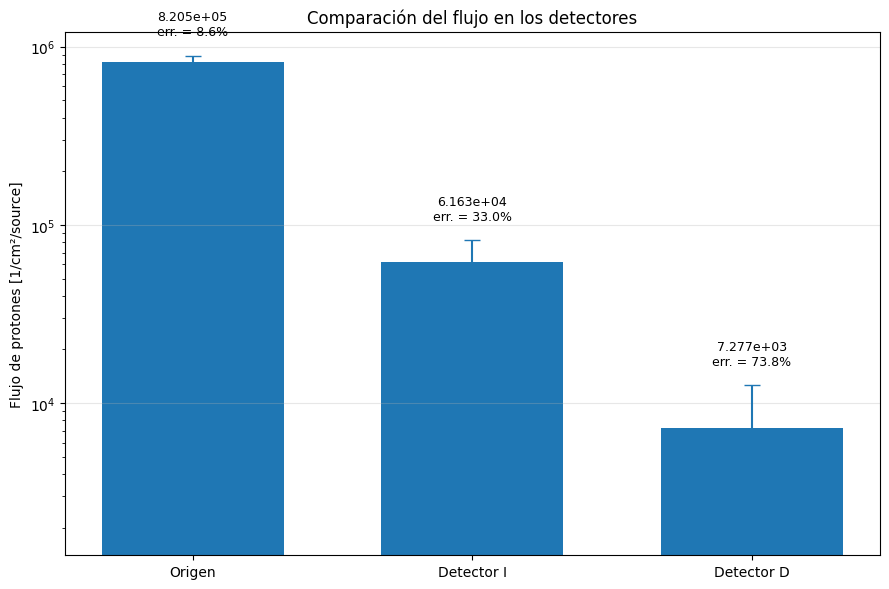

RESULTADOS

Origen
Archivo: flujo_detector_origen.out
Posición: x0 = 0.000 cm, y0 = 0.000 cm
Intervalo z: 98.380 a 98.580 cm
Flujo: 8.2048e+05 [1/cm²/source]
Error relativo: 8.56%
Error absoluto: 7.0233e+04 [1/cm²/source]
Flujo respecto del origen: 100.000%

Detector I
Archivo: flujo_detector_I.out
Posición: x0 = 5.405 cm, y0 = -6.787 cm
Intervalo z: 98.380 a 98.580 cm
Flujo: 6.1632e+04 [1/cm²/source]
Error relativo: 33.01%
Error absoluto: 2.0345e+04 [1/cm²/source]
Flujo respecto del origen: 7.512%

Detector D
Archivo: flujo_detector_D.out
Posición: x0 = -7.062 cm, y0 = -6.971 cm
Intervalo z: 98.380 a 98.580 cm
Flujo: 7.2769e+03 [1/cm²/source]
Error relativo: 73.83%
Error absoluto: 5.3725e+03 [1/cm²/source]
Flujo respecto del origen: 0.887%

COMPARACIONES
Origen / Detector I = 13.31 ± 4.54
Origen / Detector D = 112.75 ± 83.80
Detector I / Detector D = 8.47 ± 6.85


In [3]:
archivos = [
    "flujo_detector_origen.out",
    "flujo_detector_I.out",
    "flujo_detector_D.out"
]

etiquetas = [
    "Origen",
    "Detector I",
    "Detector D"
]

resultados = graficar_detectores(
    archivos,
    etiquetas
)

## dosis

In [4]:
def leer_dosis_detector(filename):
    texto = Path(filename).read_text(
        encoding="utf-8",
        errors="ignore"
    )

    def buscar_parametro(nombre):
        match = re.search(
            rf"^\s*{nombre}\s*=\s*([-\d.Ee+Dd]+)",
            texto,
            re.MULTILINE
        )

        if match is None:
            return np.nan

        return float(
            match.group(1)
            .replace("D", "E")
            .replace("d", "e")
        )

    match_titulo = re.search(
        r"^\s*title\s*=\s*(.+)$",
        texto,
        re.MULTILINE
    )

    titulo = (
        match_titulo.group(1).strip()
        if match_titulo
        else Path(filename).stem
    )

    match_tabla = re.search(
        r"#\s*z-lower\s+z-upper\s+(\S+)\s+r\.err\s*"
        r"\n\s*([-\d.Ee+Dd]+)\s+([-\d.Ee+Dd]+)\s+"
        r"([-\d.Ee+Dd]+)\s+([-\d.Ee+Dd]+)",
        texto
    )

    if match_tabla is None:
        raise ValueError(
            f"No se encontró la tabla de dosis en {filename}"
        )

    particula = match_tabla.group(1)

    zmin, zmax, dosis, error_relativo = [
        float(valor.replace("D", "E").replace("d", "e"))
        for valor in match_tabla.groups()[1:]
    ]

    return {
        "archivo": filename,
        "titulo": titulo,
        "particula": particula,
        "x0": buscar_parametro("x0"),
        "y0": buscar_parametro("y0"),
        "rmin": buscar_parametro("rmin"),
        "rmax": buscar_parametro("rmax"),
        "zmin": zmin,
        "zmax": zmax,
        "dosis": dosis,
        "error_relativo": error_relativo,
        "error_absoluto": dosis * error_relativo
    }


def graficar_dosis_detectores(
    archivos,
    etiquetas=None,
    escala_log=True,
    figsize=(9, 6)
):
    resultados = [
        leer_dosis_detector(archivo)
        for archivo in archivos
    ]

    if etiquetas is None:
        etiquetas = [
            resultado["titulo"]
            for resultado in resultados
        ]

    dosis = np.array([
        resultado["dosis"]
        for resultado in resultados
    ])

    errores_relativos = np.array([
        resultado["error_relativo"]
        for resultado in resultados
    ])

    errores_absolutos = dosis * errores_relativos

    errores_inferiores = np.minimum(
        errores_absolutos,
        dosis * 0.999999
    )

    x = np.arange(len(archivos))

    fig, ax = plt.subplots(figsize=figsize)

    barras = ax.bar(
        x,
        dosis,
        width=0.65
    )

    ax.errorbar(
        x,
        dosis,
        yerr=np.vstack([
            errores_inferiores,
            errores_absolutos
        ]),
        fmt="none",
        capsize=6,
        linewidth=1.5
    )

    for barra, valor, error in zip(
        barras,
        dosis,
        errores_relativos
    ):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor * (1 + error) * 1.25,
            f"{valor:.3e}\nerr. = {error * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas)
    ax.set_ylabel("Dosis [Gy/source]")
    ax.set_title("Dosis depositada en los detectores")
    ax.grid(axis="y", alpha=0.3)

    if escala_log:
        ax.set_yscale("log")

    plt.tight_layout()
    plt.show()

    dosis_origen = dosis[0]
    error_origen = errores_relativos[0]

    print("RESULTADOS")
    print("=" * 65)

    for etiqueta, resultado in zip(etiquetas, resultados):
        porcentaje_origen = (
            resultado["dosis"] / dosis_origen * 100
        )

        print(f"\n{etiqueta}")
        print(f"Archivo: {resultado['archivo']}")
        print(
            f"Posición: x0 = {resultado['x0']:.3f} cm, "
            f"y0 = {resultado['y0']:.3f} cm"
        )
        print(
            f"Intervalo radial: {resultado['rmin']:.3f} a "
            f"{resultado['rmax']:.3f} cm"
        )
        print(
            f"Intervalo z: {resultado['zmin']:.3f} a "
            f"{resultado['zmax']:.3f} cm"
        )
        print(
            f"Dosis: {resultado['dosis']:.4e} Gy/source"
        )
        print(
            f"Error relativo: "
            f"{resultado['error_relativo'] * 100:.2f}%"
        )
        print(
            f"Error absoluto: "
            f"{resultado['error_absoluto']:.4e} Gy/source"
        )
        print(
            f"Dosis respecto del origen: "
            f"{porcentaje_origen:.3f}%"
        )

    print("\nCOMPARACIONES")
    print("=" * 65)

    for i in range(1, len(resultados)):
        relacion = dosis_origen / dosis[i]

        error_relacion = relacion * np.sqrt(
            error_origen**2
            + errores_relativos[i]**2
        )

        print(
            f"Origen / {etiquetas[i]} = "
            f"{relacion:.2f} ± {error_relacion:.2f}"
        )

    if len(resultados) >= 3:
        relacion = dosis[1] / dosis[2]

        error_relacion = relacion * np.sqrt(
            errores_relativos[1]**2
            + errores_relativos[2]**2
        )

        print(
            f"{etiquetas[1]} / {etiquetas[2]} = "
            f"{relacion:.2f} ± {error_relacion:.2f}"
        )

    return resultados

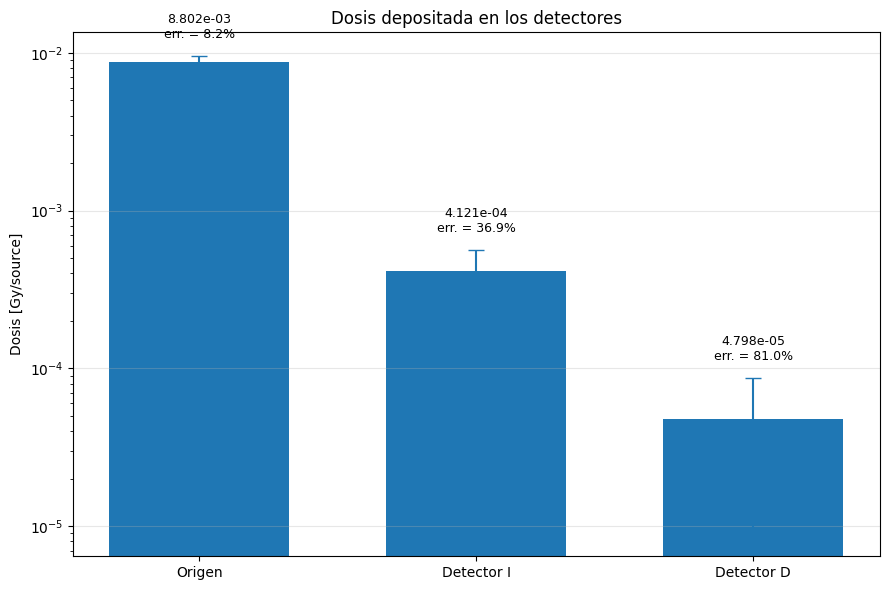

RESULTADOS

Origen
Archivo: dosis_detector_origen.out
Posición: x0 = 0.000 cm, y0 = 0.000 cm
Intervalo radial: 0.000 a 0.050 cm
Intervalo z: 98.380 a 98.580 cm
Dosis: 8.8020e-03 Gy/source
Error relativo: 8.22%
Error absoluto: 7.2352e-04 Gy/source
Dosis respecto del origen: 100.000%

Detector I
Archivo: dosis_detector_I.out
Posición: x0 = 5.405 cm, y0 = -6.787 cm
Intervalo radial: 0.000 a 0.050 cm
Intervalo z: 98.380 a 98.580 cm
Dosis: 4.1205e-04 Gy/source
Error relativo: 36.87%
Error absoluto: 1.5192e-04 Gy/source
Dosis respecto del origen: 4.681%

Detector D
Archivo: dosis_detector_D.out
Posición: x0 = -7.062 cm, y0 = -6.971 cm
Intervalo radial: 0.000 a 0.050 cm
Intervalo z: 98.380 a 98.580 cm
Dosis: 4.7978e-05 Gy/source
Error relativo: 81.00%
Error absoluto: 3.8862e-05 Gy/source
Dosis respecto del origen: 0.545%

COMPARACIONES
Origen / Detector I = 21.36 ± 8.07
Origen / Detector D = 183.46 ± 149.37
Detector I / Detector D = 8.59 ± 7.64


In [5]:
archivos = [
    "dosis_detector_origen.out",
    "dosis_detector_I.out",
    "dosis_detector_D.out"
]

etiquetas = [
    "Origen",
    "Detector I",
    "Detector D"
]

resultados_dosis = graficar_dosis_detectores(
    archivos,
    etiquetas
)